<table style="width:100%; border-bottom: 2px solid #ccc; margin-bottom: 20px;">
  <tr>
    <td style="vertical-align:middle;">
         <img src="../../resources/ADI-Logo-RGB-FullColor.png" alt="Company Logo" height="30">
    </td>
    <td style="text-align:right; vertical-align:middle;">
      <p style="margin: 0;">Phased Array Systems</p>
      <p style="font-size: 14px; margin: 0;">Iain Derrington – ADEF Group, ADI</p>
      <p style="font-size: 12px; color: #555;">Field Applications & Platform Engineer</p>
    </td>
  </tr>
</table>

# Phaser Programming

In the previous sections we looked at the Phaser hardware, which included the RF, SDR and SBC. To make the platform useful, it will require a software framework. 

Fortunately ADI has a lot of talented software engineers that make the job of programming these types of platforms relatively straight forward.  

The Linux image used on the Phaser is Kuiper Linux. Kuiper Linux is an embedded Linux distribution from Analog Devices. It is based on Raspberry Pi OS (Debian) and designed to simplify integration and development with ADI hardware (e.g. RF transceivers, data converters, mixed-signal boards).

Kuiper Linux is typically loaded with the following tools and software libraries:

- **libiio** – Hardware abstraction for IIO devices.
- **pyadi-iio** – Python interface for rapid prototyping.
- **IIO Oscilloscope** – GUI for signal visualization and device control.
- GNU Radio – SDR development with ADI blocks.
- libm2k – Support for ADALM2000 mixed-signal instrument.
- Scopy – Advanced signal analysis GUI.

In this section we are going to learn about libiio / pyadi-iio. Arguably this is possibly the most important part of this turorial.

## What is IIO

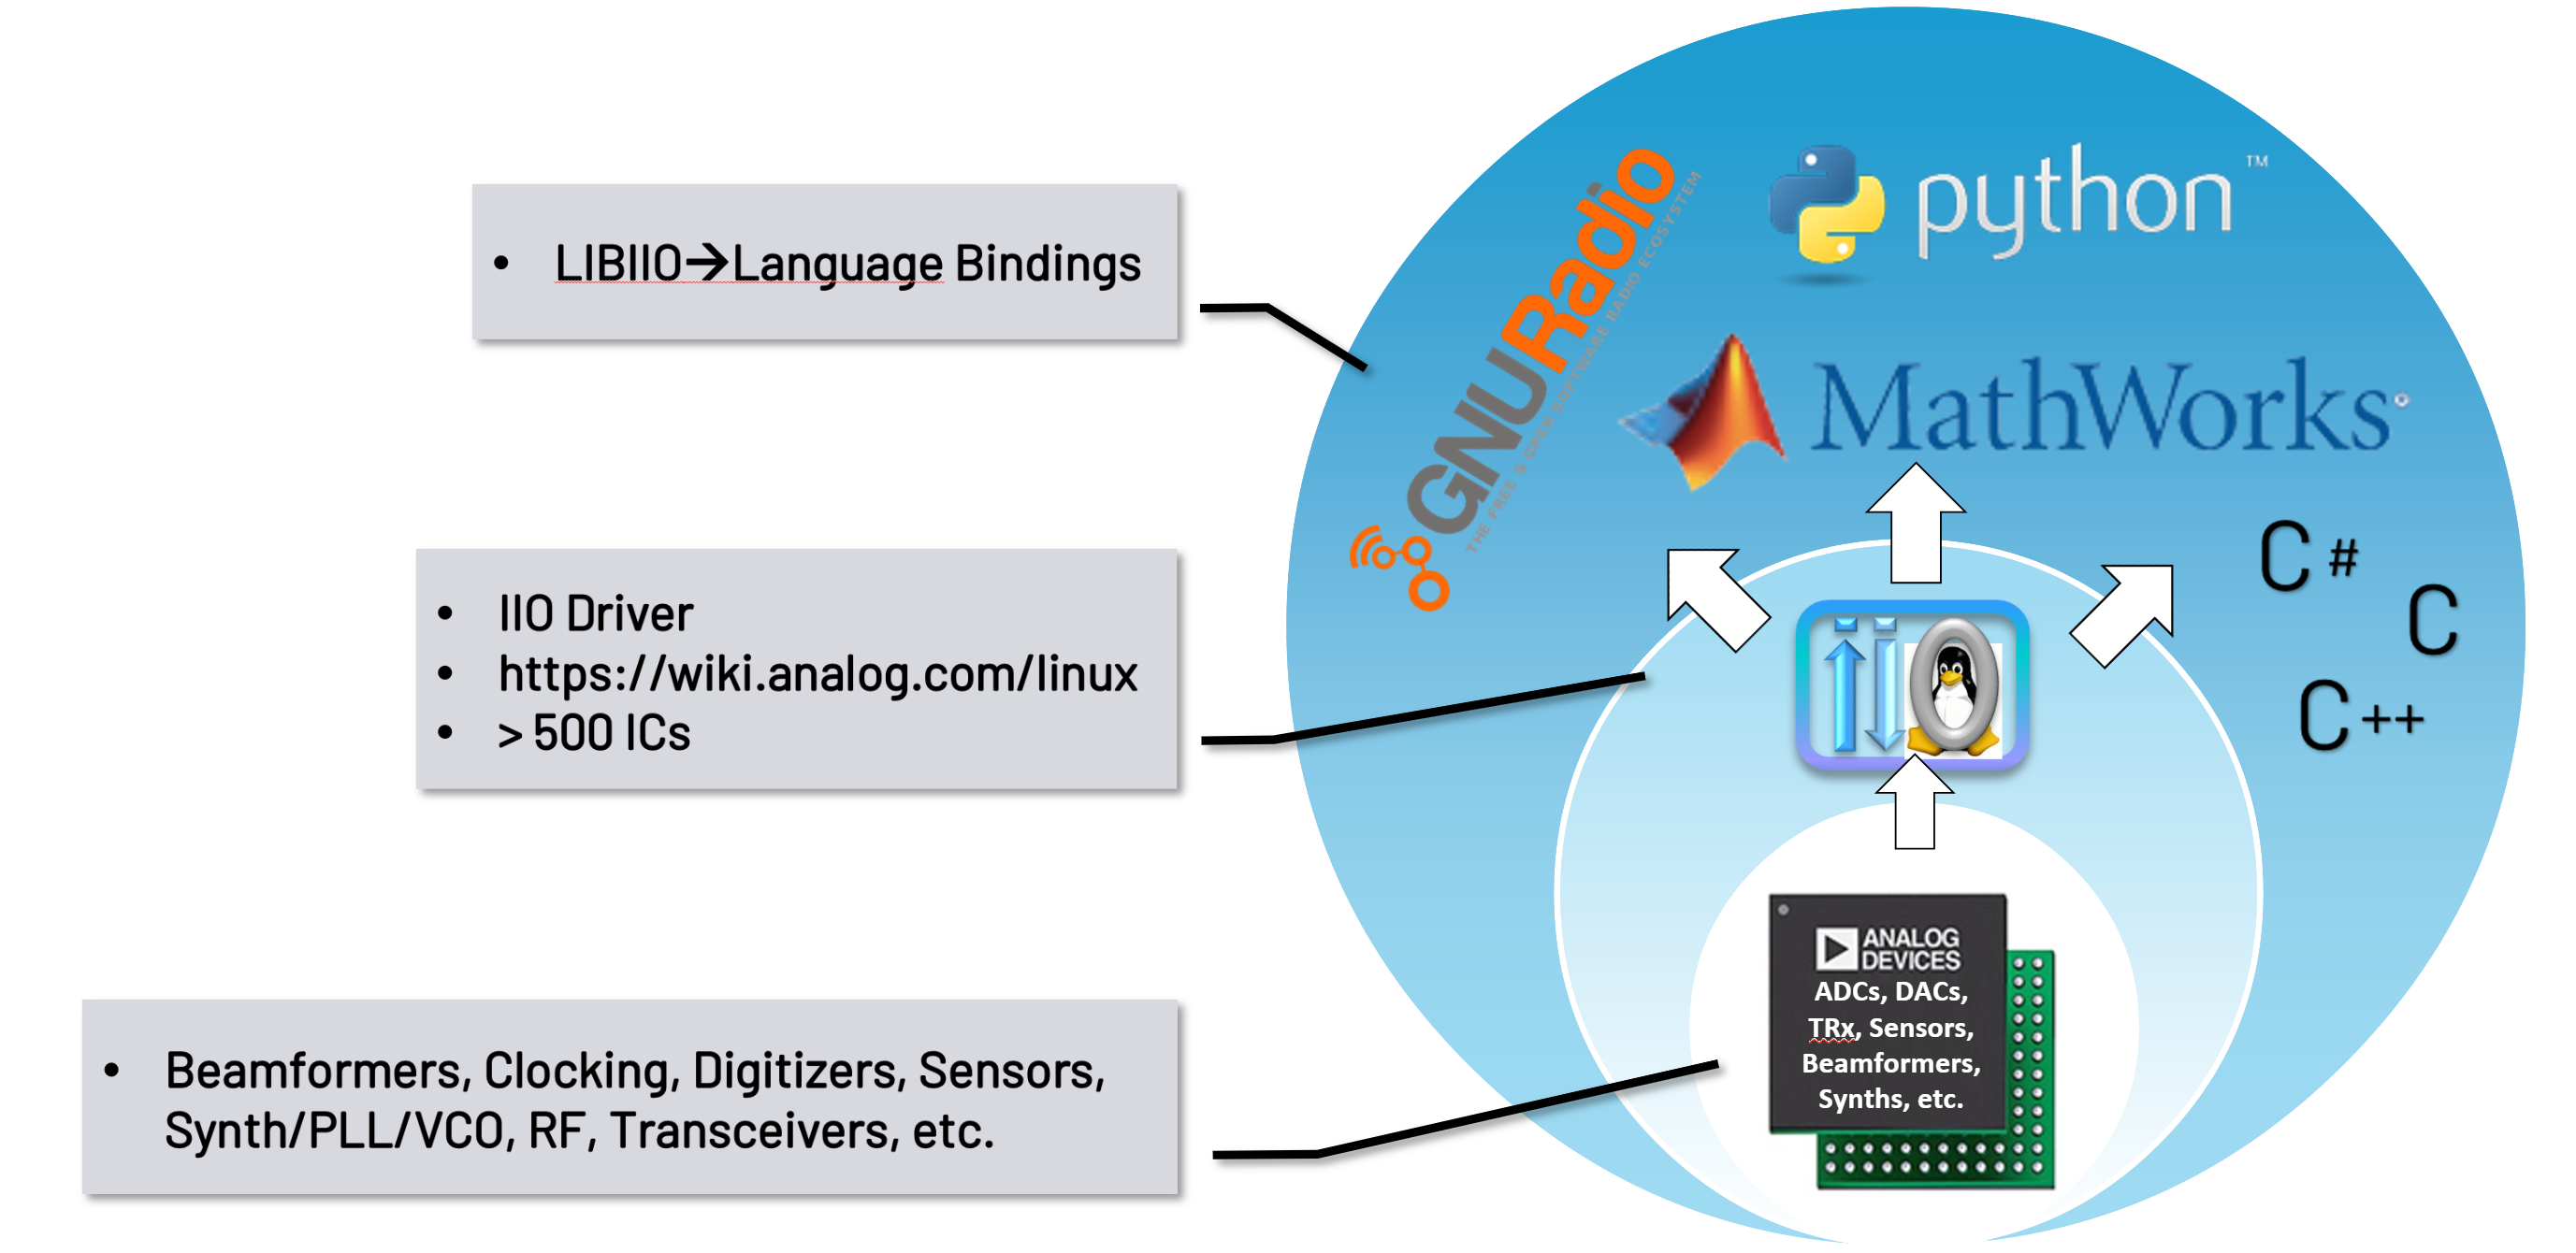

IIO (Industrial I/O) is a Linux kernel subsystem designed for high-performance data acquisition and control. 

IIO is:
- Part of the Linux kernel
- Maintained by the Linux kernel community
- Licensed under GPL / opensource
- Not just for ADI, other vendors can and do use it.  (NXP, TI, ST to name a few)
- Designed as a common interface to sensors. e.g. ADC, DACS, RF transceivers.

IIO provides a defined software interface or standard way to expose: 
- Device configuration (e.g. LO frequency, gain, phase)
- High-rate data streams (sample buffers)
- Triggers and events

Conceptually, the stack looks like this:

<div align="center">
<img src="resources/libiio-stack.drawio.svg" alt="IIO Architecture" width="600">
</div>

We are going use pyADI-IIO for this workshop, which hides some of the core concepts of libiio but makes initial development much easier.

<details>
<summary>IIO Core Concepts :)</summary>

### Contexts

Consider this as your connection to the world of IIO. The connection can be local or through an IP pipe.
A context contains all IIO devices currently registered in the system and is the entry point for discovery and interaction.

In bash, you can inspect the IIO context using the iio_info tool. This command creates a libiio context internally and prints all devices, channels, and attributes that make up the IIO system

```bash
iio_info
iio_info -u ip:192.168.2.1
iio_info -u usb
```

### Devices

A device is a representation of a piece of hardware exposed through the IIO subsystem.
Each device appears under /sys/bus/iio/devices/iio:deviceX and contains its own channels, attributes, and optional buffer interfaces.
In Python/libiio, devices are accessed through the context.

### Channels

Channels represent individual data sources or sinks within a device.
Examples include voltage0, voltage1 for ADC/DAC samples, or logical channels like altvoltage0 for LO frequency control.
Channels may be input (ADC), output (DAC), or debug/monitoring channels.
Channels also define sample data formats and can be enabled/disabled when using buffers.

### Attributes

Attributes are small pieces of configuration or status information exposed as files in sysfs.
They control or report the state of devices and channels—such as frequency, gain, scale, raw value, calibration settings, or buffer size.
Attributes are read and written as text, and they form the primary way of configuring IIO devices from user space or libiio
</details>



## Quick Play with IIO

To try out the low level commands, you need to have IIO installed on your PCs. 

It can be downloaded **[here](https://github.com/analogdevicesinc/libiio)** for various operating systems.

You will need also need libIIO installed for the examples and demos used later in the tutorials.

Whilst you can access IIO devices directly through the SysFS system on Linux, we won't be doing that today as its tedious and slow. But for those interested if you SSH into Linux device an make your way to:

```bash
root@phaser:~# cd /sys/bus/iio/devices/
root@phaser:/sys/bus/iio/devices# ls
iio:device0  iio:device1  iio:device2  iio:device3  iio:device4  iio_sysfs_trigger
root@phaser:/sys/bus/iio/devices#
```

And then use the typical Linux cmds, echo and cat to read and write to the various IIO devices.
We won't be doing that, we will start by using the libIIO convineance functions:

* `iio_info`
* 'iio_attr`

There are others, but these are the most commonly used.

You can run the following commands directly in a command prompt or you can SSH into the Pluto or Raspberry Pi and execute them there:

Firstly try...

In [1]:
!iio_info -h

Usage:
	iio_info [OPTION]...	[-x <xml_file>]
				[-u <uri>]
Options:
	-h, --help
			Show this help and quit.
	-V, --version
			Display libiio version information.
	-x, --xml [arg]
			Use the XML backend with the provided XML file.
	-u, --uri [arg]
			Use the context at the provided URI.
			eg: 'ip:192.168.2.1', 'ip:pluto.local', or 'ip:'
			    'usb:1.2.3', or 'usb:'
			    'serial:/dev/ttyUSB0,115200,8n1'
			    'local:' (Linux only)
	-S, --scan <arg>
			Scan for available backends.
			optional arg of specific backend(s)
			    'ip', 'usb' or 'ip:usb'
	-a, --auto <arg>
			Scan for available contexts and if a single context is
			available use it. <arg> filters backend(s)
			    'ip', 'usb' or 'ip:usb:'
	-T, --timeout [arg]
			Context timeout in milliseconds.
			0 = no timeout (wait forever)

This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [2]:
# Lets get some info
!iio_info --scan "ip"

Available contexts:
	0: 192.168.0.86 (cpu_thermal,rpi_volt,one-bit-adc-dac,adf4159,adar1000_1,adar1000_0,ad7291) [ip:phaser.local]
	1: 192.168.1.10 (cpu_thermal,rpi_volt,one-bit-adc-dac,adf4159,adar1000_1,adar1000_0,ad7291) [ip:phaser.local]
	2: fe80::bb79:b606:1017:cc9c%18 (cpu_thermal,rpi_volt,one-bit-adc-dac,adf4159,adar1000_1,adar1000_0,ad7291) [ip:phaser.local]
	3: 192.168.2.1 (Analog Devices PlutoSDR Rev.C (Z7010-AD9361)), serial=104473e6a60f000c1100220059411784fe [ip:pluto.local]


In [3]:
# Lets look at the devices
!iio_attr -u "ip:192.168.1.10" -d

IIO context has 8 devices:
	hwmon0, cpu_thermal: found 0 device attributes
	hwmon1, rpi_volt: found 0 device attributes
	iio:device0, gpios: found 0 device attributes
	iio:device1, pll0: found 0 device attributes
	iio:device2, BEAM1: found 39 device attributes
	iio:device3, BEAM0: found 39 device attributes
	iio:device4, housekeeping_adc: found 0 device attributes
	iio_sysfs_trigger: found 2 device attributes


In [4]:
!iio_attr -u "ip:192.168.1.10" iio:device2 -c

dev 'BEAM1', channel 'voltage3', id 'RX' (input), found 10 channel-specific attributes
dev 'BEAM1', channel 'voltage2', id 'RX' (input), found 10 channel-specific attributes
dev 'BEAM1', channel 'voltage1', id 'TX' (output), found 14 channel-specific attributes
dev 'BEAM1', channel 'voltage2', id 'TX' (output), found 14 channel-specific attributes
dev 'BEAM1', channel 'voltage0', id 'RX' (input), found 10 channel-specific attributes
dev 'BEAM1', channel 'voltage0', id 'TX' (output), found 14 channel-specific attributes
dev 'BEAM1', channel 'voltage3', id 'TX' (output), found 14 channel-specific attributes
dev 'BEAM1', channel 'voltage1', id 'RX' (input), found 10 channel-specific attributes
dev 'BEAM1', channel 'temp0' (input), found 1 channel-specific attributes


In [5]:
!iio_attr -u "ip:192.168.1.10" iio:device2 -c voltage0

dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'attenuation', value '1'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'beam_pos_load', value '0'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'beam_pos_save', value '0, 0, 0, 0.000000'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'bias_set_load', value '1'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'bias_set_save', value '1, 0, 0, 0, 0'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'hardwaregain', value '127'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'phase', value '0.000000'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'powerdown', value '0'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'sequence_end', value '0'
dev 'BEAM1', channel 'voltage0' (input), id 'RX', attr 'sequence_start', value '0'
dev 'BEAM1', channel 'voltage0' (output), id 'TX', attr 'attenuation', value '0'
dev 'BEAM1', channel 'voltage0' (output), id 'TX', attr 'beam_pos_load', valu

In [6]:
!iio_attr -u "ip:192.168.1.10" iio:device2 -c voltage0 hardwaregain

127
1


In [7]:
!iio_attr -u "ip:192.168.1.10" iio:device2 -c voltage0 hardwaregain -o 1

1


As you have seen, its a little fiddly and slow to use SysFS or the command line libIIO tools to access these device.  
Fortunately we have high level bindings that make it easy. Were going to be making use of two of these bindings.

* [pylibiio](https://pypi.org/project/pylibiio/): Python libIIO module
* pyadi-iio: A conveniance wrapper for libIIO



## What is pyADI-IIO?

**pyADI-IIO** is Analog Devices’ high-level Python library that wraps IIO *devices* with object-oriented interfaces. It simplifies complex register operations into Pythonic APIs.

Benefits of pyADI-IIO:
- No need to write raw SPI/I2C or register code
- **Device-specific classes like `CN0566`, `ad9363`, `ltc2992`, etc.**
- Easy to prototype and automate in Jupyter Notebooks or scripts
- Cross-platform: works on Linux, Windows, Raspberry Pi, and more

The code written with pyADI-IIO is easy to read and understand.
```python
import adi

# Create a device interface
sdr = adi.ad9361()

# Configure properties
sdr.rx_rf_bandwidth = 4000000
sdr.rx_lo = 2000000000
sdr.tx_lo = 2000000000
sdr.tx_cyclic_buffer = True
sdr.tx_hardwaregain = -30
sdr.gain_control_mode = "slow_attack"

# Read back properties from hardware
print(sdr.rx_hardwaregain)
```

---

We will be running the Python applications in this tutorial on a host PC. The PC will communicate with the Phaser board over two Ethernet ports:

- One port will be for the Raspberry Pi. The Raspberrty Pi controls the GPIO, SPI/I2C used to configure the various devices on the Phaser kit.
- The other will be for the Pluto SDR (Ethernet over USB).

<div align="center">
<img src="resources/host-config.png" alt="Host Configuration" width="600">
</div>

Please be aware this is not the only configuration that the Phaser can be used in. Many of the online examples and demos are run directly on the Raspberry Pi. Thus the Pluto is connected directly to the Raspberry Pi.

## Controlling Devices Directly

While all of the examples in this tutorial use Python and the `pyADI-IIO` library, control of the CN0566 hardware is not limited to Python alone.

The underlying IIO framework is **language-agnostic** and supports multiple interfaces and languages including:

- **MATLAB** (via Instrument Control Toolbox + libiio)
- **C/C++** (via `libiio`)
- **Rust, Go, Julia, Node.js** (through community bindings)
- **Shell scripting** (using CLI tools like `iio_attr`, `iio_info`, `iio_readdev`, `iio_writedev`)
- **LabVIEW** (via shared libraries)

---

### Direct Control on the Raspberry Pi

You can also **SSH into the Raspberry Pi** on the CN0566 platform and issue commands directly using either:

#### sysfs Interface (for low-level attributes)
```bash
cat /sys/bus/iio/devices/iio:device0/in_voltage0_raw
echo 1 > /sys/bus/iio/devices/iio:device0/out_voltage0_enable
```

#### IIO CLI tools
```bash
iio_attr -d adar1000-phy voltage0 phase
iio_attr -d adar1000-phy voltage3 gain 64
```




## Lets Run Some Code!!!

1st Lets import some useful modules and set up the basics:

In [8]:
print("Running...\n")

try:
    print("Importing Modules:")
    import os
    print("Os")
    import sys
    sys.path.insert(0, '../src')

    import sys
    # for p in sys.path:
    #    print(p)
    
    import matplotlib.pyplot as plt
    print("matplotlib")
    import numpy as np
    print("numpy")
    from adi import ad9361
    from adi.cn0566 import CN0566
    print("PyADI-IIO")
    from pathlib import Path
    print("pathlib")
    from phaser_functions import save_hb100_cal, spec_est
    from phaser_init import init_phaser_sdr
    print("Phaser Helper Functions\n")
    
    
    
except Exception as ex:
    print(f"Failed to import all packages, check all dependancies are installed {ex}")
    sys.exit(1)

def get_phaser_root():
    """
    Fixes some of the issues with running in Notebooks and VSCode
    """
    try:
        # .py script
        current_path = Path(__file__).resolve()
    except NameError:
        # Jupyter notebook
        current_path = Path().resolve()

    for parent in [current_path] + list(current_path.parents):
        if parent.name.lower() == "phaser":
            return parent.resolve()

    raise RuntimeError(
        f"Could not locate 'phaser' folder from path: {current_path}\n"
        "Make sure you're running from within the 'phaser' project hierarchy."
        "If running in VSCode attach to .venv and not ipykernal."
    )

# Use it
phaser_root = get_phaser_root()
resource_path = phaser_root / "resources"
print(f"phaser_root: {phaser_root}")
print(f"Resource path: {resource_path}")

"""
Lets add some style
"""
plt.style.use('ggplot')
np.set_printoptions(legacy='1.25', precision=2)


"""
These lines simply extract the resource folder location
The resource folder is common to many of the Phaser demos and stores cal values
"""
CN0566_IP_ADDRS = "192.168.1.10"
PLUTO_IP_ADDRS = "192.168.2.1"

print("\nComplete!")

Running...

Importing Modules:
Os
matplotlib
numpy
PyADI-IIO
pathlib
Phaser Helper Functions

phaser_root: C:\ADI Repo\Phaser
Resource path: C:\ADI Repo\Phaser\resources

Complete!


## Connecting Phaser Kit

The following cell attempts to connect to both the Pluto SDR and the Rasberry Pi.
If successfull the sdr object (my_sdr) is passed to the __my_phaser__(class CN0566) object as an argument...

In [9]:
try:
    print(f"Attempting to connect to CN0566 via ip:{CN0566_IP_ADDRS}...")
    my_phaser = CN0566(uri="ip:" + CN0566_IP_ADDRS)
    
    print(f"Found CN0566. Connecting to PlutoSDR via ip:{PLUTO_IP_ADDRS}...")
    
    my_sdr = ad9361(uri="ip:" + PLUTO_IP_ADDRS)
    print("PlutoSDR connected :)")

except:
    print("Unable to connect to CN0566 or PlutoSDR. Please check the IP addresses and connections.")
    sys.exit(1)
    
# Set my_phaser.sdr to instance of Pluto SDR
my_phaser.sdr = my_sdr 
my_phaser.sdr._ctx.set_timeout(10000)  # 10 seconds

print("\nComplete...")

Attempting to connect to CN0566 via ip:192.168.1.10...
Found CN0566. Connecting to PlutoSDR via ip:192.168.2.1...
PlutoSDR connected :)

Complete...


## Configure Phaser for Use Case

If everything above has executed without errory we now have a **my_phaser** object which exposes many properties and methods that configure, control and monitor the phaser kit.


First things first we need to configure the kit for a particular use case. So lets define this.

1. Rx Only Mode (We're using the HB100 as the transmit signal for this workshop)
2. Configure SDR Rx LO Frequency to 2.2GHz
3. Configure SDR sampling data rate to 30MSPS
4. Configure the LO to generate the correct frequency for mixing down from aprx 10.5GHz

In [10]:

freq_sdr = int(2.2e9)            # SDR internal LO = 2.2 GHz 
freq_sample = int(30e6)          # SDR baseband SPS = 30MSPS
my_phaser.signalFreq = 10.525e9  # Front end frequency 10.525 GHz


"""
Initialise Pluto
"""
print(f"Initialise Pluto\n")

my_phaser.configure(device_mode="rx")
init_phaser_sdr(my_phaser, freq_sample, freq_sdr, rx_gain=6, tx_gain=-6, buffer_size=1024)

print(f"Converter Sample Rate = {freq_sample/1e6} Msps")
print(f"SDR Tx frequency = {freq_sdr} GHz (Not used)")
print(f"SDR Rx frequency = {freq_sdr/1e9} GHz (Pluto Rx LO)")
print(f"Tx Gain = -6")
print(f"Rx Gain =  6")
print(f"Buffer size = 1024 bytes \n")


#  Configure SDR specific parameters.
my_sdr.filter = resource_path / "LTE20_MHz.ftr"  # Load LTE 20 MHz filter

# To disable tx, set attenuation to a high value and set frequency far from rx.
my_sdr.tx_hardwaregain_chan0 = int(-88)  # this is a negative number between 0 and -88
my_sdr.tx_hardwaregain_chan1 = int(-88)
my_sdr.tx_lo = int(1.0e9)

"""
Configure PLL
"""
my_phaser.signalFreq = 10.525e9
my_phaser.frequency = (int(my_phaser.signalFreq) + freq_sdr ) // 4  # PLL feedback via /4 VCO output
my_phaser.freq_dev_step = 5690
my_phaser.freq_dev_range = 0
my_phaser.freq_dev_time = 0
my_phaser.powerdown = 0
my_phaser.ramp_mode = "disabled"

print(f"Complete")

Initialise Pluto

Loaded filter: C:\ADI Repo\Phaser\beam-forming-tutorials\..\resources\LTE20_MHz.ftr
Converter Sample Rate = 30.0 Msps
SDR Tx frequency = 2200000000 GHz (Not used)
SDR Rx frequency = 2.2 GHz (Pluto Rx LO)
Tx Gain = -6
Rx Gain =  6
Buffer size = 1024 bytes 

Complete


If everything above has executed without errory we now have a **my_phaser** object which exposes many properties and methods that configure, control and monitor the phaser kit.
This next cell is all about setting up the phaser for our very first run. As its our first run I've gone in to detail for each line and what it does.

# Code Breakdown: Phaser and SDR Initialization

This section describes the initialization process for the CN0566 Phaser system and PlutoSDR using pyADI-IIO. Each line is explained in context.

```python
my_phaser.configure(device_mode="rx")
```

- Configures all beamformer devices in devices for receive mode.
    - Each device is prepared for SPI-based manual control.
    - All 4 receive channels are enabled with gain applied.
    - External switches are enabled and set for Rx polarity.
    - Registers are programmed directly to ensure beamformer operation is consistent and predictable.

If were to step into 
```python 
my_phaser.SDR_init(freq_sample, 1e9, freq_sdr, 6, -6, 1024)
``` 
we would uncover the following. We won't delve too deep into this but I think it maybe useful to get a basic understanding.

```python
my_phaser.sdr._ctrl.debug_attrs["adi,frequency-division-duplex-mode-enable"].value = "1"
my_phaser.sdr._ctrl.debug_attrs["adi,ensm-enable-txnrx-control-enable"].value = "0"  # Disable pin control so spi can move the states
my_phaser.sdr._ctrl.debug_attrs["adi,initialize"].value = "1"
```

Here are acessing low level IIO methods:
In pylibiio (not pyadi-iio), **_ctrl** points to the underlying iio device object. The proceeding underscore is there to let you know this is an advanced features. Please click below to see **some** of the methods and attributes accessible through _ctrl
<details>
<summary><strong>More Information: _ctrl Methods and Attributes</strong></summary>
<h3>Identification & Metadata</h3>
<div style="margin-left: 0; text-align: left; display: inline-block;">
<table style="text-align: left">
  <thead>
    <tr>
      <th>Name</th>
      <th>Type</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>name</code></td>
      <td><code>str</code></td>
      <td>Logical name of the device (e.g. "cf-ad9361-lpc")</td>
    </tr>
    <tr>
      <td><code>id</code></td>
      <td><code>str</code></td>
      <td>Device ID string (e.g. "iio:device2")</td>
    </tr>
    <tr>
      <td><code>context</code></td>
      <td><code>iio.Context</code></td>
      <td>Parent IIO context (e.g. local or remote)</td>
    </tr>
  </tbody>
</table>

</div>

<h3>Attributes</h3>
<div style="margin-left: 0; text-align: left; display: inline-block;">
<table style="text-align: left">
  <thead>
    <tr>
      <th>Name</th>
      <th>Type</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>attrs</code></td>
      <td><code>dict</code></td>
      <td>Key-value interface for <strong>standard device attributes</strong> (e.g. sampling frequency)</td>
    </tr>
    <tr>
      <td><code><b>debug_attrs</b></code></td>
      <td><code>dict</code></td>
      <td>Key-value interface for <strong>debugfs attributes</strong>, typically vendor/device specific</td>
    </tr>
    <tr>
      <td><code>channels</code></td>
      <td><code>list</code></td>
      <td>List of <code>iio.Channel</code> objects (both input and output)</td>
    </tr>
    <tr>
      <td><code>find_channel(name, is_output=False)</code></td>
      <td><code>iio.Channel</code></td>
      <td>Locate a specific channel by name</td>
    </tr>
  </tbody>
</table>
</div>

<h3>Channel Enablement</h3>
<div style="margin-left: 0; text-align: left; display: inline-block;">
<table style="text-align: left">
  <thead>
    <tr>
      <th>Name</th>
      <th>Return</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>enable_all_channels()</code></td>
      <td><code>None</code></td>
      <td>Enables all input/output channels for buffer streaming</td>
    </tr>
    <tr>
      <td><code>disable_all_channels()</code></td>
      <td><code>None</code></td>
      <td>Disables all streaming channels</td>
    </tr>
  </tbody>
</table>
</div>

<h3>Buffer Interface</h3>
<div style="margin-left: 0; text-align: left; display: inline-block;">
<table style="text-align: left">
  <thead>
    <tr>
      <th>Name</th>
      <th>Return</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>create_buffer(length, cyclic)</code></td>
      <td><code>iio.Buffer</code></td>
      <td>Creates a buffer for streaming. <code>cyclic=True</code> loops data</td>
    </tr>
    <tr>
      <td><code>buffers_enabled</code></td>
      <td><code>bool</code></td>
      <td>Returns <code>True</code> if buffer streaming is enabled</td>
    </tr>
  </tbody>
</table>

</div>
</details>
<br>

In our code we are using **_ctrl.debug_attrs** to control some none standard, or SDR specific attrubutes:

<div style="margin-left: 0; text-align: left; display: inline-block;">

<table>
  <thead>
    <tr>
      <th>Attribute Name</th>
      <th>Purpose</th>
      <th>Value Meaning</th>
      <th>Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>adi,frequency-division-duplex-mode-enable</code></td>
      <td>Enables <strong>FDD mode</strong>: allows simultaneous Tx and Rx using separate frequencies</td>
      <td><code>"1"</code> = FDD enabled<br><code>"0"</code> = TDD</td>
      <td>Must be set before initialization</td>
    </tr>
    <tr>
      <td><code>adi,ensm-enable-txnrx-control-enable</code></td>
      <td>Enables or disables <strong>ENSM pin control</strong> (<code>TXNRX</code>, <code>ENABLE</code> hardware signals)</td>
      <td><code>"1"</code> = pin control<br><code>"0"</code> = SPI</td>
      <td>Set to <code>"0"</code> to allow software control from <code>pyadi-iio</code></td>
    </tr>
    <tr>
      <td><code>adi,initialize</code></td>
      <td>Triggers <strong>full AD9361 initialization</strong> with current settings (LO, bandwidth, etc.)</td>
      <td><code>"1"</code> = execute init</td>
      <td>Required after setting duplex mode, ENSM control, or other pre-init configurations</td>
    </tr>
  </tbody>
</table>
</div>

Next we enable the Rx channels enable a single kernel-space IIO buffer and channel volage0 we enable quadrature tracking.
```python
my_phaser.sdr.rx_enabled_channels = [0, 1]              
my_phaser.sdr._rxadc.set_kernel_buffers_count(1)    

rx = my_phaser.sdr._ctrl.find_channel("voltage0")
rx.attrs["quadrature_tracking_en"].value = "1"         
```

The remaining parts of the code use high level methods that are relatively easy to understand.

In [11]:
# Code to configure the phaser kit
print("Running...\n")
"""
configure is a phaser method that performs a large chunk of the phaser setup.
Including:
TODO
"""
my_phaser.configure(device_mode="rx")

"""
Example of accessing not standard IIO attributes
"""
my_phaser.sdr._ctrl.debug_attrs["adi,frequency-division-duplex-mode-enable"].value = "1" # Enable FDD
my_phaser.sdr._ctrl.debug_attrs["adi,ensm-enable-txnrx-control-enable"].value = "0"  # Disable pin control so spi can move the states
my_phaser.sdr._ctrl.debug_attrs["initialize"].value = "1"

"""
Using high level methods to setup the phaser
"""
my_phaser.sdr.rx_enabled_channels = [0, 1]              # Enable Rx1 (voltage0) and Rx2 (voltage1)
my_phaser.sdr._rxadc.set_kernel_buffers_count(1)        # No stale buffers to flush

"""
Example of accessing standard IIO attributes
"""
rx = my_phaser.sdr._ctrl.find_channel("voltage0")
rx.attrs["quadrature_tracking_en"].value = "1"          # enable quadrature tracking

my_sdr.sample_rate = int(30000000)                      # Sampling rate  = 30MHz
my_sdr.rx_buffer_size = int(4 * 256)
my_sdr.rx_rf_bandwidth = int(10e6)

# We must be in manual gain control mode (otherwise we won't see the peaks and nulls!)
my_phaser.sdr.gain_control_mode_chan0 = "manual"  # DISable AGC
my_phaser.sdr.gain_control_mode_chan1 = "manual"
my_phaser.sdr.rx_hardwaregain_chan0 = 0  # dB
my_phaser.sdr.rx_hardwaregain_chan1 = 0  # dB

my_phaser.sdr.rx_lo = int(2.0e9)  # Downconvert by 2GHz  # Receive Freq

my_phaser.sdr.filter = resource_path / "LTE20_MHz.ftr"  # Handy filter for fairly widdeband measurements

"""
Make sure the Tx channels are attenuated (or off) and their freq is far away from Rx
this is a negative number between 0 and -88
"""
my_phaser.sdr.tx_hardwaregain_chan0 = int(-80)
my_phaser.sdr.tx_hardwaregain_chan1 = int(-80)

"""
Configure CN0566 parameters.
ADF4159 and ADAR1000 array attributes are exposed directly, although normally
accessed through other methods.
"""
my_phaser.SignalFreq = 10.525e9                 # Set initial PLL frequency to HB100 nominal
my_phaser.lo = int(my_phaser.SignalFreq) + my_sdr.rx_lo

import time
time.sleep(1)

gain_list = [64] * 8
for i in range(0, len(gain_list)):
    my_phaser.set_chan_gain(i, gain_list[i], apply_cal=False)

time.sleep(1)

# Aim the beam at boresight (zero degrees). Place HB100 right in front of array.
my_phaser.set_beam_phase_diff(0.0)

# Averages decide number of time samples are taken to plot and/or calibrate system. By default it is 1.
my_phaser.Averages = 8

print("\nComplete!")

Running...


Complete!


# Begin Receiving Data
Now the Phaser is configured we can capture data.
The code below captures RF on both receiver inputs from 10GHz to 10.5GHz in 10MHz steps. At each step the the signals are summed.

Point the reference 10.5GHz signal toward to the phaser and execute the script below.

Frequency: 10.00 GHz Max Signal: 5.10
Frequency: 10.01 GHz Max Signal: 5.39
Frequency: 10.02 GHz Max Signal: 5.10
Frequency: 10.03 GHz Max Signal: 4.47
Frequency: 10.04 GHz Max Signal: 5.39
Frequency: 10.05 GHz Max Signal: 5.10
Frequency: 10.06 GHz Max Signal: 4.47
Frequency: 10.07 GHz Max Signal: 4.47
Frequency: 10.08 GHz Max Signal: 4.47
Frequency: 10.09 GHz Max Signal: 5.10
Frequency: 10.10 GHz Max Signal: 5.00
Frequency: 10.11 GHz Max Signal: 6.32
Frequency: 10.12 GHz Max Signal: 5.10
Frequency: 10.13 GHz Max Signal: 5.10
Frequency: 10.14 GHz Max Signal: 5.39
Frequency: 10.15 GHz Max Signal: 5.10
Frequency: 10.16 GHz Max Signal: 5.10
Frequency: 10.17 GHz Max Signal: 4.47
Frequency: 10.18 GHz Max Signal: 6.32
Frequency: 10.19 GHz Max Signal: 5.00
Frequency: 10.20 GHz Max Signal: 4.47
Frequency: 10.21 GHz Max Signal: 5.39
Frequency: 10.22 GHz Max Signal: 5.00
Frequency: 10.23 GHz Max Signal: 5.39
Frequency: 10.24 GHz Max Signal: 5.39
Frequency: 10.25 GHz Max Signal: 5.10
Frequency: 1

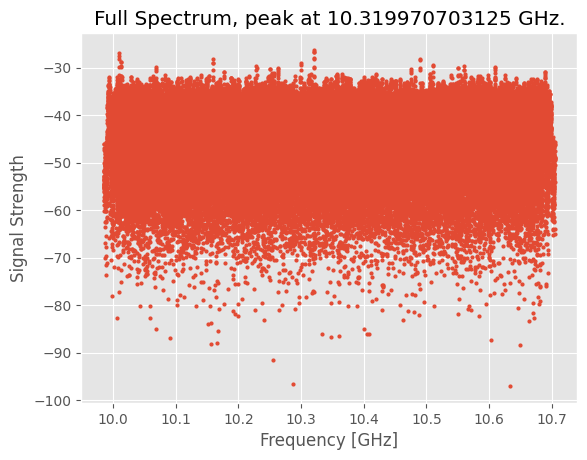

Save cal file? (y or n) n


In [12]:
# Sweep and capture data
""" 
Set up range of frequencies to sweep. Sample rate is set to 30Msps,
for a total of 30MHz of bandwidth (quadrature sampling)
Filter is 20MHz LTE, so you get a bit less than 20MHz of usable
bandwidth. Set step size to something less than 20MHz to ensure
complete coverage.
"""
f_start = 10.0e9
f_stop = 10.7e9
f_step = 10e6

# Initialize arrays for amplitudes, frequencies
full_ampl = np.empty(0)
full_freqs = np.empty(0)

for freq in range(int(f_start), int(f_stop), int(f_step)):
    my_phaser.signalFreq = freq
    my_phaser.frequency = ( int(my_phaser.signalFreq) + my_sdr.rx_lo) // 4  # PLL feedback via /4 VCO output

    # Read back data from pluto Rx buffer
    data = my_phaser.sdr.rx()
    
    # Sum data from both channels
    data_sum = data[0] + data[1]
    
    print(f"Frequency: {freq/1e9:4.2f} GHz Max Signal: {np.max(abs(data_sum)):4.2f}")
    

    """
    FFT is taken of windowed data and scaled for dBFs
    spec_est returns frequency and amplitude bins
    """
    ampl, freqs = spec_est(data_sum, 30000000, ref=2 ^ 12, plot=False)
    ampl = np.fft.fftshift(ampl)                           # Shift the zero-frequency component to the center of the spectrum
    ampl = np.flip(ampl)                                   # Just an experiment...
    
    freqs = np.fft.fftshift(freqs)                         # Shift the zero-frequency component to the center of the spectrum
    freqs += freq
    full_freqs = np.concatenate((full_freqs, freqs))
    full_ampl = np.concatenate((full_ampl, ampl))

full_freqs /= 1e9  # Hz -> GHz

peak_index = np.argmax(full_ampl)
peak_freq = full_freqs[peak_index]
print("Peak frequency found at ", full_freqs[peak_index], " GHz.")

plt.figure(2)
plt.title("Full Spectrum, peak at " + str(full_freqs[peak_index]) + " GHz.")
plt.plot(full_freqs, full_ampl, linestyle="", marker="o", ms=2)
plt.xlabel("Frequency [GHz]")
plt.ylabel("Signal Strength")
plt.show()


prompt = input("Save cal file? (y or n)")
if prompt.upper() == "Y":
    save_hb100_cal(peak_freq * 1e9, filename=resource_path / "hb100_freq_val.pkl")


## More Information

https://www.youtube.com/watch?v=8WaVkb5osRs </br>
https://www.youtube.com/watch?v=Yx3RPOtv7x8&t=4618s